<a href="https://colab.research.google.com/github/angelonavarrogit/S100-analitica-datos/blob/main/S100_Equipo7_ParteI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Paso 1: Cargar la base de datos y verificar dimensiones

In [ ]:
import pandas as pd
df = pd.read_csv('netflix_titles.csv')
print("Filas y Columnas:", df.shape)

Filas y Columnas: (8807, 12)


# Paso 2: Porcentaje de datos faltantes globales y por columna

In [ ]:
total_celdas = df.shape[0] * df.shape[1]
total_faltantes = df.isnull().sum().sum()
pct_global_faltantes = (total_faltantes / total_celdas) * 100
print(f"Porcentaje de faltantes en total: {pct_global_faltantes:.2f}%\n")
pct_faltantes_columna = (df.isnull().sum() / len(df)) * 100
print("Porcentaje de faltantes por columna:")
print(pct_faltantes_columna.round(2))

Porcentaje de faltantes en total: 4.08%

Porcentaje de faltantes por columna:
show_id          0.00
type             0.00
title            0.00
director        29.91
cast             9.37
country          9.44
date_added       0.11
release_year     0.00
rating           0.05
duration         0.03
listed_in        0.00
description      0.00
dtype: float64


# Paso 3: Estadísticos de la Variable Objetivo (type)

In [ ]:
print("Valores únicos y conteo:")
print(df['type'].value_counts())

print("\nModa (categoría más frecuente):", df['type'].mode()[0])
print("Mínimo alfabético:", df['type'].min())
print("Máximo alfabético:", df['type'].max())
print("Porcentaje de faltantes:", df['type'].isnull().mean() * 100)

Valores únicos y conteo:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Moda (categoría más frecuente): Movie
Mínimo alfabético: Movie
Máximo alfabético: TV Show
Porcentaje de faltantes: 0.0


# Paso 4: Estadísticos de Predictora 1 (release_year)

In [ ]:
print("Media:", df['release_year'].mean().round(2))
print("Mediana:", df['release_year'].median())
print("Mínimo:", df['release_year'].min())
print("Máximo:", df['release_year'].max())
print("Porcentaje de faltantes:", df['release_year'].isnull().mean() * 100)

Media: 2014.18
Mediana: 2017.0
Mínimo: 1925
Máximo: 2021
Porcentaje de faltantes: 0.0


# Paso 5: Estadísticos de Predictora 2 (country)

In [ ]:
print("Moda (País más frecuente):", df['country'].mode()[0])
print("Porcentaje de faltantes:", (df['country'].isnull().mean() * 100).round(2))

Moda (País más frecuente): United States
Porcentaje de faltantes: 9.44


# Paso 6: Estadísticos de Predictora 3 (listed_in)

In [ ]:
print("Moda (Categoría más frecuente):", df['listed_in'].mode()[0])
print("Porcentaje de faltantes:", (df['listed_in'].isnull().mean() * 100).round(2))

Moda (Categoría más frecuente): Dramas, International Movies
Porcentaje de faltantes: 0.0


# Figura

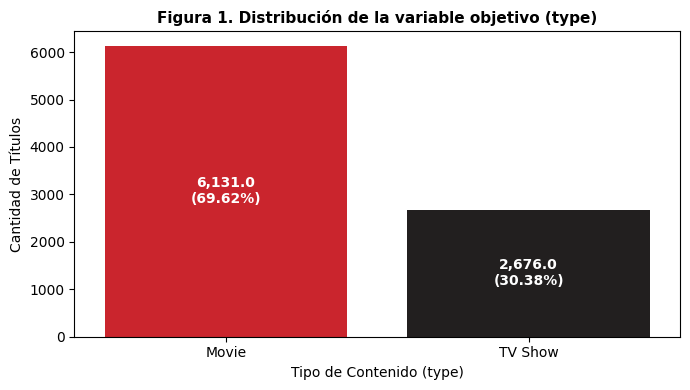

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el tamaño de la figura
plt.figure(figsize=(7, 4))

# Crear el gráfico de barras ajustado
ax = sns.countplot(
    data=df,
    x='type',
    hue='type',
    palette=['#E50914', '#221F1F'],
    legend=False
)

# Títulos y etiquetas de ejes
plt.title('Figura 1. Distribución de la variable objetivo (type)', fontsize=11, fontweight='bold')
plt.xlabel('Tipo de Contenido (type)', fontsize=10)
plt.ylabel('Cantidad de Títulos', fontsize=10)

# Etiquetar cada barra con su valor exacto y porcentaje
total_titulos = len(df)
for p in ax.patches:
    altura = p.get_height()
    pct = f'{(altura / total_titulos) * 100:.2f}%'
    ax.annotate(f'{altura:,}\n({pct})',
                (p.get_x() + p.get_width() / 2., altura / 2),
                ha='center', va='center', fontsize=10, color='white', fontweight='bold')

plt.tight_layout()
# Guardar la imagen en el directorio local del proyecto
plt.savefig('figura_1_distribucion.png', dpi=300)
plt.show()